In [1]:
# Plotting country mortality changes spatially

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter, create_global_country_map

In [2]:
# === Path config ===
MORT_DIR = "/glade/work/awells/air_quality/CESM/mortality/ozone/"

ssp245_file = "Mortality_Country_sum_CESM2_SSP245_2020-2068.nc"
ssp245_path = os.path.join(MORT_DIR, ssp245_file)
ssp245 = xr.open_dataarray(ssp245_path)

arise_file = "Mortality_Country_sum_CESM2_ARISE_2035-2068.nc"
arise_path = os.path.join(MORT_DIR, arise_file)
arise = xr.open_dataarray(arise_path)

g6_file = "Mortality_Country_sum_CESM2_G6-1.5K_2035-2083.nc"
g6_path = os.path.join(MORT_DIR, g6_file)
g6 = xr.open_dataarray(g6_path)

In [3]:
decades = [slice(2035, 2039),
           slice(2040, 2049),
           slice(2050, 2059),
           slice(2060, 2068)]

In [4]:
def plot_mortality(da, health_VAR, year, SAVE_DIR, SCENARIO):
    # assign levels
    levels = [-10000, -5000, -1000, -500, -100, -50, 0, 50, 100, 500, 1000, 5000, 10000]

    # Create figure and layout
    fig = plt.figure(figsize=autosize_figure(1, 1, scale_factor=1.3))
    gs = GridSpec(2, 1, height_ratios=[15, 1])

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # Plot map
    ax = fig.add_subplot(gs[0, 0], projection=projection)
    cb = da.plot(
        transform=crs,
        add_colorbar=False,
        cmap='RdBu_r',
        levels=levels,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"{health_VAR} Mortality in {year}\n {SCENARIO} - SSP2-4.5", fontsize=16)

    # Colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label(f"Mortality change due to ozone", fontsize=13)

    plt.tight_layout()

    out_file = f"Mortality_mean_{health_VAR}_{year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

Plotting decade 2035-2039
Plotting decade 2040-2049
Plotting decade 2050-2059
Plotting decade 2060-2068


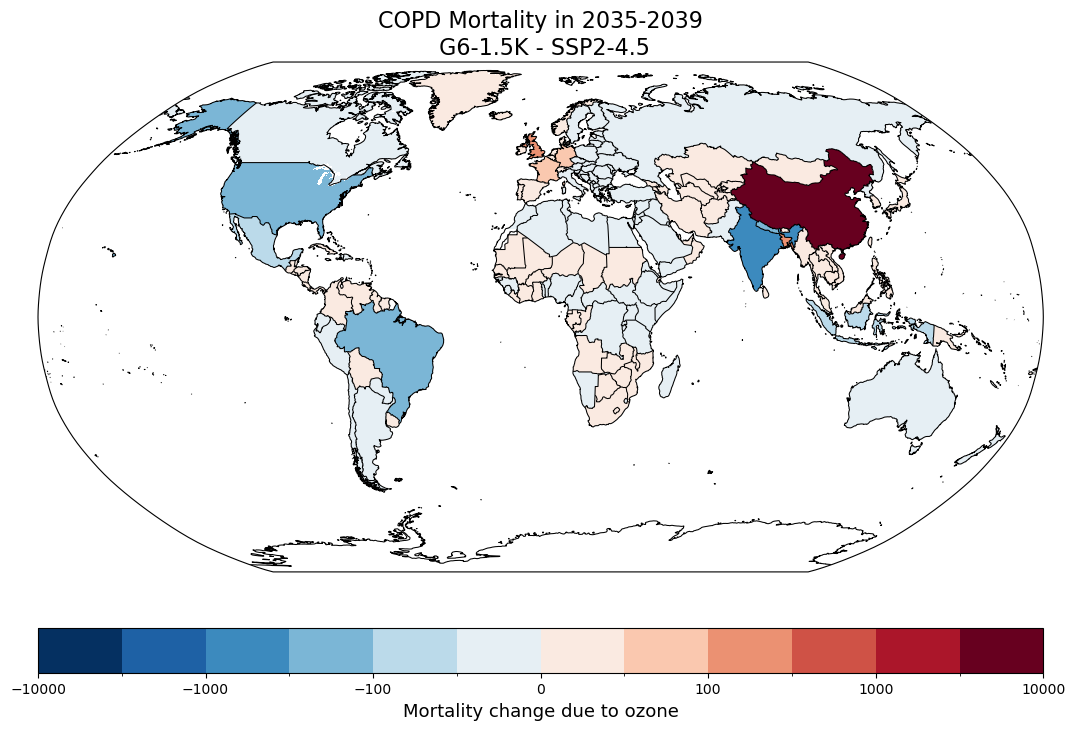

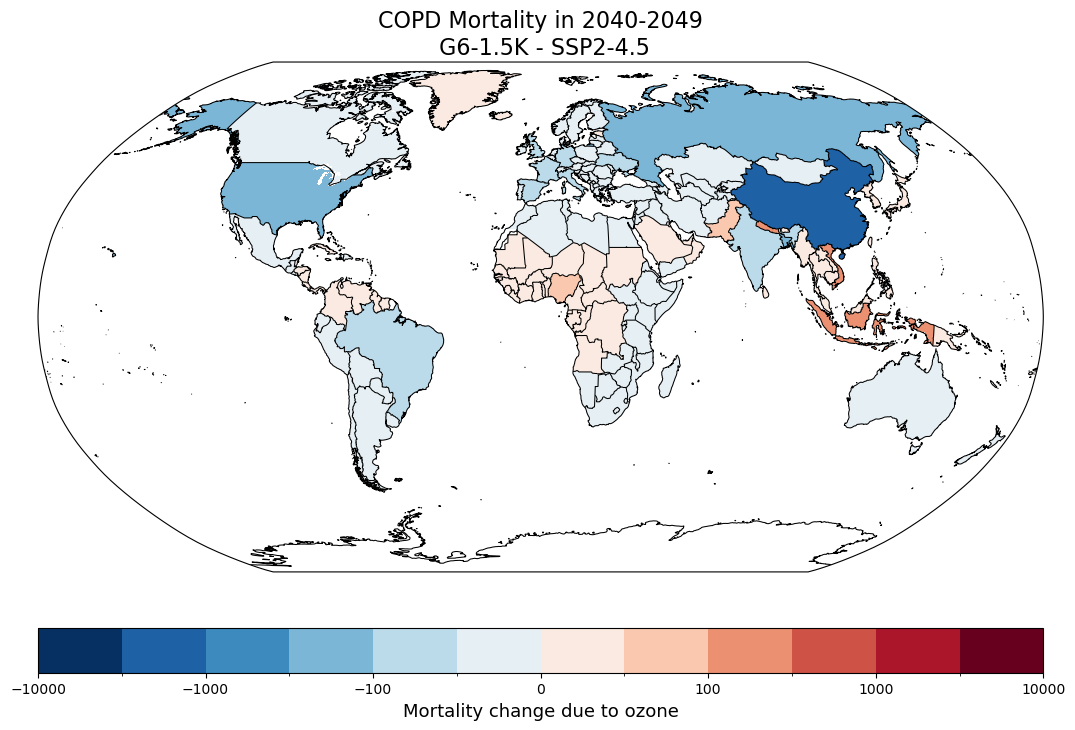

In [ ]:
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/"

for decade in decades:
    ssp245_decade = ssp245.sel(year=decade).mean("year")
    g6_decade = g6.sel(year=decade).mean("year")

    difference = g6_decade - ssp245_decade
    global_map_difference = create_global_country_map(difference).mean("ensemble")

    print(f"Plotting decade {decade.start}-{decade.stop}")
    plot_mortality(land_filter(global_map_difference), "COPD", f"{decade.start}-{decade.stop}", SAVE_DIR, "G6-1.5K")

Plotting decade 2035-2039
Plotting decade 2040-2049
Plotting decade 2050-2059
Plotting decade 2060-2068


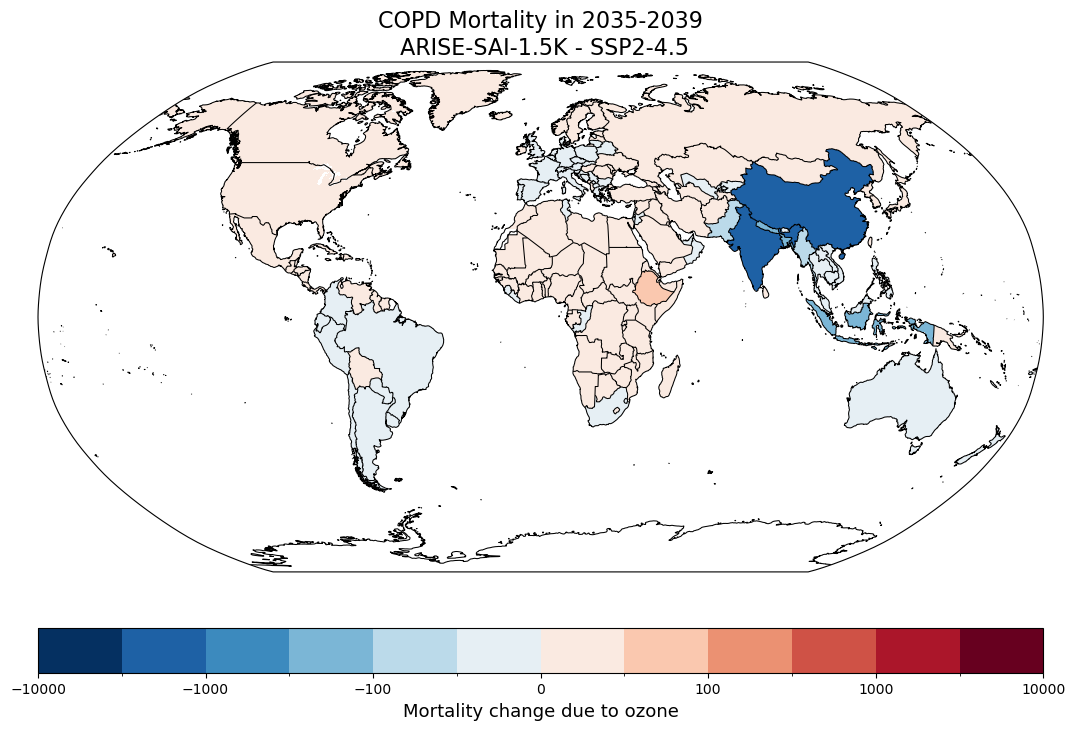

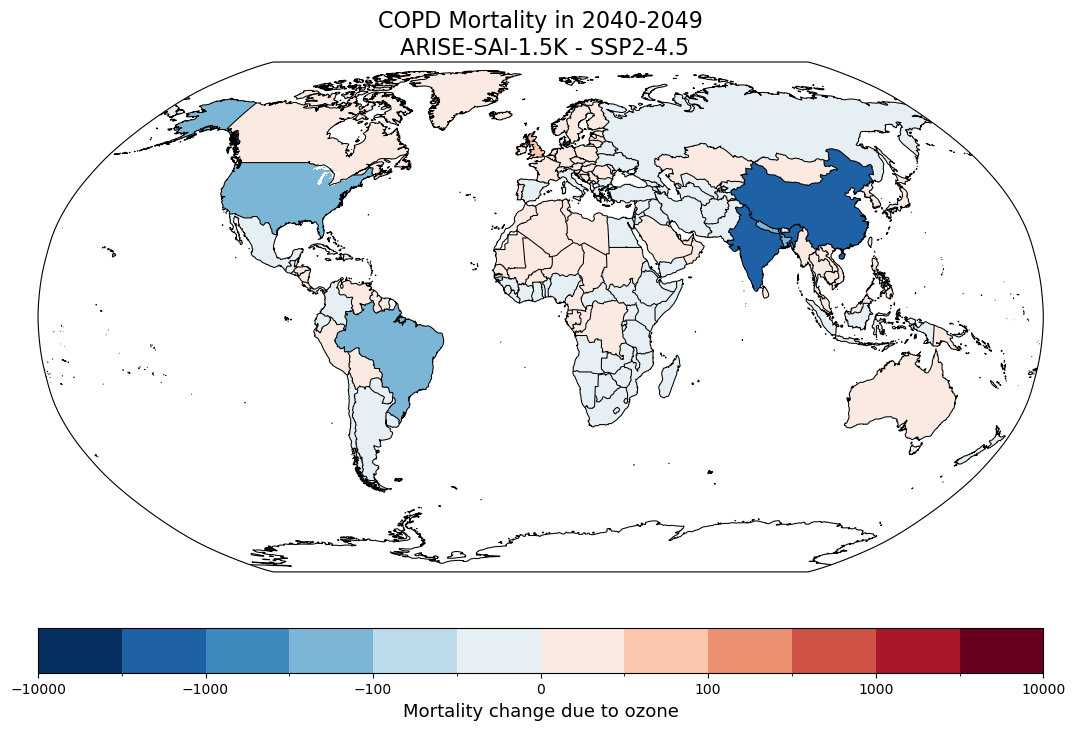

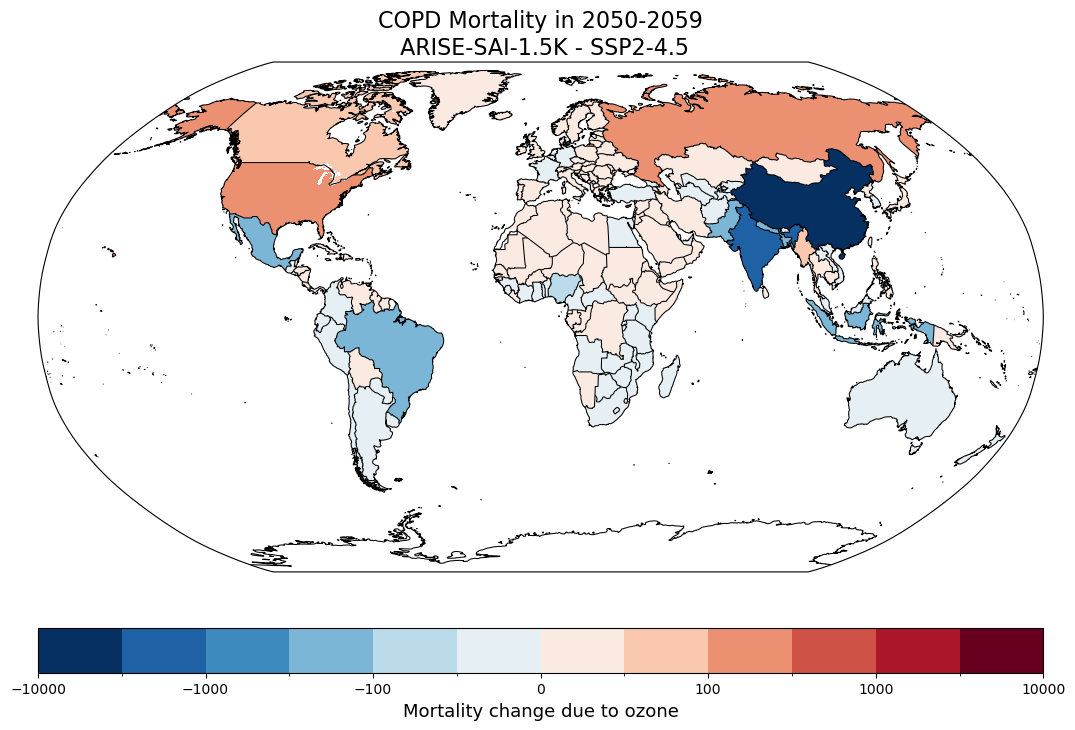

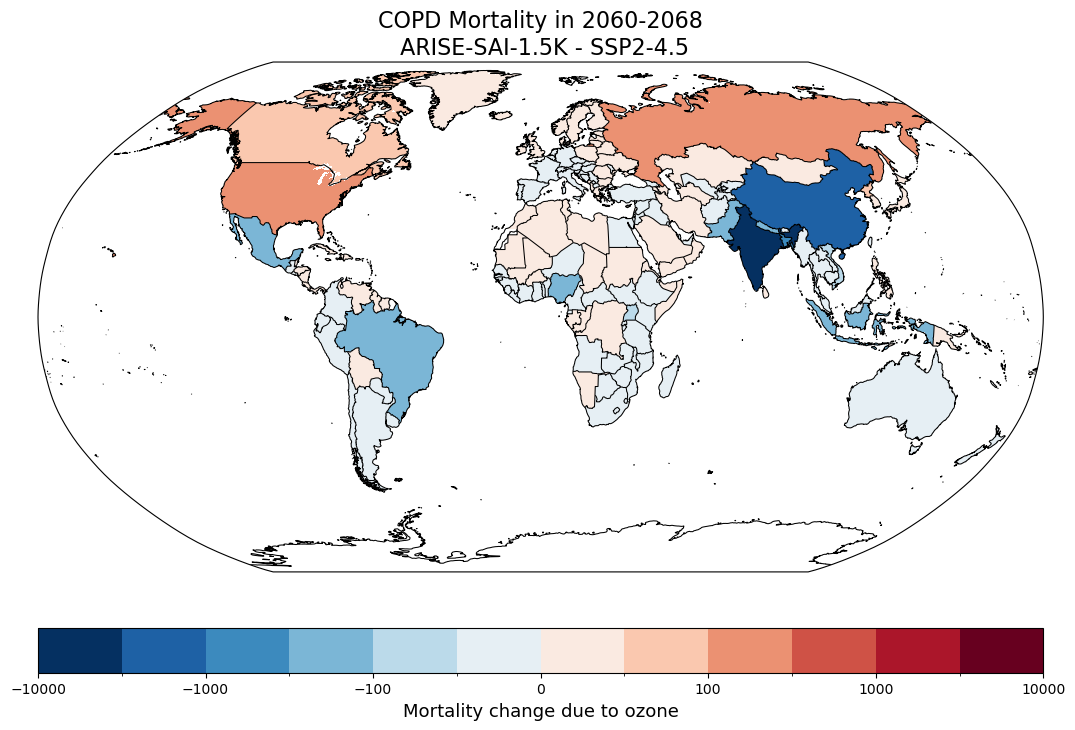

In [6]:
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/"

for decade in decades:
    ssp245_decade = ssp245.sel(year=decade).mean("year")
    arise_decade = arise.sel(year=decade).mean("year")

    difference = arise_decade - ssp245_decade
    global_map_difference = create_global_country_map(difference).mean("ensemble")

    print(f"Plotting decade {decade.start}-{decade.stop}")
    plot_mortality(land_filter(global_map_difference), "COPD", f"{decade.start}-{decade.stop}", SAVE_DIR)